In [15]:
#Libraries
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
import requests
import time

In [16]:
df = pd.read_csv('data.csv')
df.head()
len(df)

169909

In [17]:
# Convert string → actual list
df['artists'] = df['artists'].apply(ast.literal_eval)

# One row per artist
df_exploded = df.explode('artists')

# Count songs per artist
artist_counts = df_exploded['artists'].value_counts()

print(artist_counts.head(20))

artists
Francisco Canaro           2234
Эрнест Хемингуэй           1215
Frédéric Chopin            1035
Ludwig van Beethoven        976
Wolfgang Amadeus Mozart     938
Johann Sebastian Bach       868
Эрих Мария Ремарк           781
Igor Stravinsky             739
Frank Sinatra               732
Giuseppe Verdi              691
Billie Holiday              685
Arturo Toscanini            632
Ignacio Corsini             620
Vladimir Horowitz           614
Johnny Cash                 588
New York Philharmonic       582
Bob Dylan                   553
The Rolling Stones          522
The Beach Boys              503
Lata Mangeshkar             502
Name: count, dtype: int64


In [18]:
df_exploded['year']

0         1928
1         1928
1         1928
2         1928
3         1928
          ... 
169906    2020
169906    2020
169907    2020
169907    2020
169908    2020
Name: year, Length: 225456, dtype: int64

In [19]:
print(artist_counts.describe())
print((artist_counts >= 10).sum())

count    27622.00000
mean         8.16219
std         32.47829
min          1.00000
25%          1.00000
50%          2.00000
75%          5.00000
max       2234.00000
Name: count, dtype: float64
4263


In [20]:
ts_songs = df_exploded[df_exploded['artists'].str.lower() == 'taylor swift']

In [21]:
API_KEY = "f254d1334087cd7a1955a6b411b3a428"
lastfm_data = []

for song in ts_songs['name']:
    url = f"http://ws.audioscrobbler.com/2.0/?method=track.getInfo&api_key={API_KEY}&artist=TAYLOR+SWIFT&track={song}&format=json"
    response = requests.get(url)
    data = response.json()
    
    if 'track' in data:
        playcount = data['track'].get('playcount', None)
        listeners = data['track'].get('listeners', None)
        lastfm_data.append({'name': song, 'playcount': playcount, 'listeners': listeners})
    else:
        lastfm_data.append({'name': song, 'playcount': None, 'listeners': None})
    
    time.sleep(0.25)

In [22]:
lastfm_df = pd.DataFrame(lastfm_data)
lastfm_df.head()

,name,playcount,listeners
0,Tell Me Why,2404796,336757
1,Long Live,5777515,485870
2,Innocent,3514589,381899
3,Dear John,6463776,533633
4,Superman,1918024,221451


In [23]:
ts_songs_enriched = ts_songs.merge(
    lastfm_df,
    on='name',
    how='left'
)

ts_songs_enriched.head()

,id,name,artists,duration_ms,release_date,year,acousticness,danceability,energy,instrumentalness,...,loudness,speechiness,tempo,valence,mode,key,popularity,explicit,playcount,listeners
0,4XrP7vKBjKLEYlRZdb0Ygr,Tell Me Why,Taylor Swift,200560,11/11/08,2008,0.0606,0.601,0.852,0.000003,...,-3.096,0.0386,100.015,0.513,1,7,44,0,2404796,336757
1,4XrP7vKBjKLEYlRZdb0Ygr,Tell Me Why,Taylor Swift,200560,11/11/08,2008,0.0606,0.601,0.852,0.000003,...,-3.096,0.0386,100.015,0.513,1,7,44,0,2404796,336757
2,6XDBA3QWX51lDJ0oZbaJJN,Long Live,Taylor Swift,317947,10/25/10,2010,0.0360,0.418,0.680,0.000076,...,-4.300,0.0346,204.125,0.142,1,7,47,0,5777515,485870
3,6XDBA3QWX51lDJ0oZbaJJN,Long Live,Taylor Swift,317947,10/25/10,2010,0.0360,0.418,0.680,0.000076,...,-4.300,0.0346,204.125,0.142,1,7,47,0,5777515,485870
4,3kfgJql90tzgoxByioAMXR,Innocent,Taylor Swift,302253,10/25/10,2010,0.1860,0.552,0.608,0.000000,...,-5.290,0.0259,134.050,0.170,0,1,47,0,3514589,381899


                                            name       artists  year  \
13                             Should've Said No  Taylor Swift  2006   
47                               Picture To Burn  Taylor Swift  2006   
58                             Should've Said No  Taylor Swift  2006   
57                                    Tim McGraw  Taylor Swift  2006   
41                                    Tim McGraw  Taylor Swift  2006   
..                                           ...           ...   ...   
182                     Death By A Thousand Cuts  Taylor Swift  2019   
183       Miss Americana & The Heartbreak Prince  Taylor Swift  2019   
44    Death By A Thousand Cuts - Live From Paris  Taylor Swift  2020   
195  Only The Young - Featured in Miss Americana  Taylor Swift  2020   
206            Cornelia Street - Live From Paris  Taylor Swift  2020   

     period_5yr  similarity_to_first5 playcount listeners  
13         2005              0.788291   6430728    568699  
47         2005

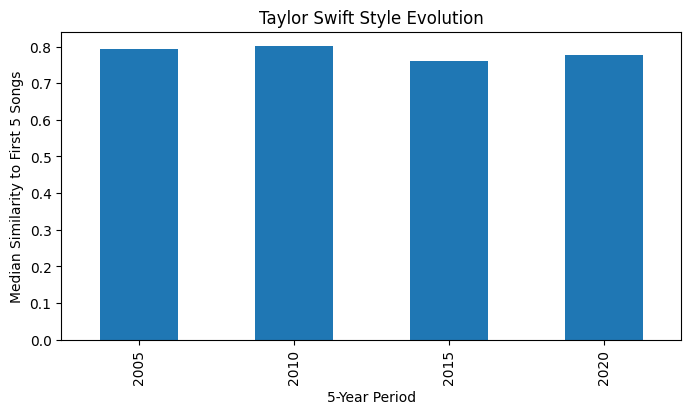

In [24]:
ts_songs_final = ts_songs_enriched.copy()

# --- Step 0: Keep only unique songs by track ID ---
ts_demo = ts_songs_final[ts_songs_final['artists'] == 'Taylor Swift'].copy()
ts_demo = ts_demo.drop_duplicates(subset='id').reset_index(drop=True)

# --- Step 1: Add 5-year bins ---
ts_demo['period_5yr'] = (ts_demo['year'] // 5) * 5

# --- Step 2: Scale audio features manually to 0-1 ---
features = ['danceability','energy','acousticness','valence','tempo']
for f in features:
    min_val = ts_demo[f].min()
    max_val = ts_demo[f].max()
    ts_demo[f] = (ts_demo[f] - min_val) / (max_val - min_val)

# --- Step 3: Compute first-5-song baseline ---
first_5 = ts_demo.sort_values('year').head(5)
baseline = first_5[features].mean().values

# --- Step 4: Compute similarity to baseline ---
def similarity_to_baseline(row):
    dist = np.linalg.norm(row.values - baseline)/np.sqrt(len(features))
    return 1 - dist  # higher = more similar

ts_demo['similarity_to_first5'] = ts_demo[features].apply(similarity_to_baseline, axis=1)

# --- Step 5: Keep demo table columns ---
demo_table = ts_demo[['name','artists','year','period_5yr','similarity_to_first5','playcount','listeners']].sort_values('year')
print(demo_table)

# --- Step 6: Optional plot ---
plt.figure(figsize=(8,4))
ts_demo.groupby('period_5yr')['similarity_to_first5'].median().plot(kind='bar')
plt.xlabel('5-Year Period')
plt.ylabel('Median Similarity to First 5 Songs')
plt.title('Taylor Swift Style Evolution')
plt.show()

In [25]:
ts_demo.tail()

,id,name,artists,duration_ms,release_date,year,acousticness,danceability,energy,instrumentalness,...,tempo,valence,mode,key,popularity,explicit,playcount,listeners,period_5yr,similarity_to_first5
202,1B5VzXPqMlvRw0U4HJY3dJ,I Wish You Would,Taylor Swift,207440,10/27/14,2014,0.016072,0.596694,0.931490,0.000049,...,0.356271,0.519392,1,0,51,0,8816429,609971,2010,0.818823
203,2zfgVd034GlUvk7LqBHl6u,I Know Places,Taylor Swift,195707,10/27/14,2014,0.252165,0.512397,0.765625,0.000000,...,0.658052,0.499273,1,0,51,0,8459973,572307,2010,0.854322
204,7I7JbDv63ZJJsSi24DyJrz,Dancing With Our Hands Tied,Taylor Swift,211507,11/10/17,2017,0.062014,0.548760,0.688702,0.000011,...,0.658476,0.263440,0,0,65,0,15635347,678237,2015,0.784611
205,5hQSXkFgbxjZo9uCwd11so,False God,Taylor Swift,200307,8/23/19,2019,0.757932,0.738843,0.242788,0.000147,...,0.082308,0.338326,0,11,69,0,17065726,713094,2015,0.644851
206,3fGnrtrtL1IHSX9t4DKOYf,Cornelia Street - Live From Paris,Taylor Swift,296013,5/18/20,2020,0.595180,0.347107,0.413462,0.000000,...,0.205489,0.285794,1,11,70,0,2869555,219895,2020,0.768755


In [26]:
ts_demo = ts_demo.sort_values('year').reset_index(drop=True)
cumulative_baseline = ts_demo[features].expanding().mean().shift(1)  # previous songs only

ts_demo['similarity_to_previous'] = [
    1 - np.linalg.norm(ts_demo.loc[i, features].values - cumulative_baseline.loc[i].values)/np.sqrt(len(features))
    for i in range(len(ts_demo))
]

In [27]:
period_avg = ts_demo.groupby('period_5yr')[features].transform('mean')
ts_demo['similarity_to_period'] = 1 - np.linalg.norm(ts_demo[features].values - period_avg.values, axis=1)/np.sqrt(len(features))

In [28]:
ts_demo.tail()

,id,name,artists,duration_ms,release_date,year,acousticness,danceability,energy,instrumentalness,...,mode,key,popularity,explicit,playcount,listeners,period_5yr,similarity_to_first5,similarity_to_previous,similarity_to_period
202,2dgFqt3w9xIQRjhPtwNk3D,Death By A Thousand Cuts,Taylor Swift,198533,8/23/19,2019,0.467451,0.694215,0.737981,0.00000,...,1,4,70,0,15022636,640925,2015,0.798712,0.806199,0.817295
203,214nt20w5wOxJnY462klLw,Miss Americana & The Heartbreak Prince,Taylor Swift,234147,8/23/19,2019,0.028639,0.611570,0.756010,0.00615,...,0,11,71,0,NaN,NaN,2015,0.822572,0.862408,0.840864
204,3oF7Or7T35yhQbGxbCGvRX,Death By A Thousand Cuts - Live From Paris,Taylor Swift,199067,5/17/20,2020,0.733211,0.482645,0.645433,0.00000,...,1,4,65,0,1496701,163765,2020,0.776433,0.719898,0.857887
205,2slqvGLwzZZYsT4K4Y1GBC,Only The Young - Featured in Miss Americana,Taylor Swift,157507,1/31/20,2020,0.002310,0.442975,0.795673,0.00000,...,0,5,73,0,3008161,270109,2020,0.838494,0.824337,0.781486
206,3fGnrtrtL1IHSX9t4DKOYf,Cornelia Street - Live From Paris,Taylor Swift,296013,5/18/20,2020,0.595180,0.347107,0.413462,0.00000,...,1,11,70,0,2869555,219895,2020,0.768755,0.758356,0.844479


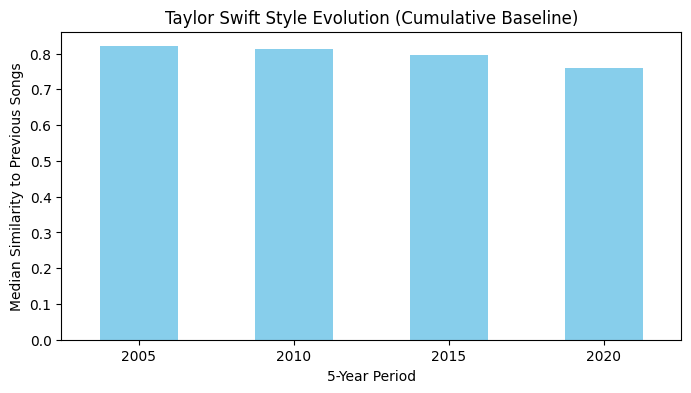

In [36]:
# --- Step 0: Keep only unique songs ---
ts_demo = ts_songs_final[ts_songs_final['artists'] == 'Taylor Swift'].copy()
ts_demo = ts_demo.drop_duplicates(subset='id').reset_index(drop=True)

# --- Step 1: Add 5-year bins ---
ts_demo['period_5yr'] = (ts_demo['year'] // 5) * 5

# --- Step 2: Normalize audio features manually ---
features = ['danceability','energy','acousticness','valence','tempo']
for f in features:
    min_val = ts_demo[f].min()
    max_val = ts_demo[f].max()
    ts_demo[f] = (ts_demo[f] - min_val) / (max_val - min_val)

# --- Step 3: Compute cumulative baseline similarity ---
ts_demo = ts_demo.sort_values('year').reset_index(drop=True)
similarities = []
for i in range(len(ts_demo)):
    if i == 0:
        similarities.append(1.0)  # first song baseline
    else:
        baseline = ts_demo.loc[:i-1, features].mean().values
        dist = np.linalg.norm(ts_demo.loc[i, features].values - baseline)/np.sqrt(len(features))
        similarities.append(1 - dist)

ts_demo['similarity_to_cumulative'] = similarities

# --- Step 4: Plot similarity over 5-year periods ---
plt.figure(figsize=(8,4))
median_per_period = ts_demo.groupby('period_5yr')['similarity_to_cumulative'].median()
median_per_period.plot(kind='bar', color='skyblue')
plt.xlabel('5-Year Period')
plt.ylabel('Median Similarity to Previous Songs')
plt.title('Taylor Swift Style Evolution (Cumulative Baseline)')
plt.xticks(rotation=0)
plt.show()

In [30]:
ts_demo
ts_demo.columns

Index(['id', 'name', 'artists', 'duration_ms', 'release_date', 'year',
       'acousticness', 'danceability', 'energy', 'instrumentalness',
       'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'mode',
       'key', 'popularity', 'explicit', 'playcount', 'listeners', 'period_5yr',
       'similarity_to_cumulative'],
      dtype='str')

In [31]:
# Current columns
cols = ts_demo.columns.tolist()

# Desired order: put popularity, playcount, listeners after key audio features
new_order = [
    'id','name','artists','year','release_date','duration_ms', 'popularity',
    'acousticness','danceability','energy','instrumentalness','liveness','loudness',
    'speechiness','tempo','valence','mode','key','playcount','listeners',
    'period_5yr','similarity_to_cumulative'
]

ts_demo = ts_demo[new_order]

# Check new order
print(ts_demo.head())

                       id               name       artists  year release_date  \
0  0T2kNwYw4Z7rhziNRNsjfO  Should've Said No  Taylor Swift  2006     10/24/06   
1  32mVHdy0bi1XKgr0ajsBlG    Picture To Burn  Taylor Swift  2006     10/24/06   
2  16MVSD0mGI4RMQT83Qzm69  Should've Said No  Taylor Swift  2006     10/24/06   
3  0Om9WAB5RS09L80DyOfTNa         Tim McGraw  Taylor Swift  2006     10/24/06   
4  7DQmwd7zye9xvzMQJnD8S8         Tim McGraw  Taylor Swift  2006     10/24/06   

   duration_ms  popularity  acousticness  danceability    energy  ...  \
0       244080          52      0.009923      0.305785  0.769231  ...   
1       173067          61      0.178000      0.604959  0.912260  ...   
2       242200          58      0.010407      0.304132  0.792067  ...   
3       232107          60      0.592090      0.476033  0.448317  ...   
4       234547          55      0.618872      0.466116  0.457933  ...   

   loudness  speechiness     tempo   valence  mode  key  playcount  listen

In [32]:
ts_demo.head()

,id,name,artists,year,release_date,duration_ms,popularity,acousticness,danceability,energy,...,loudness,speechiness,tempo,valence,mode,key,playcount,listeners,period_5yr,similarity_to_cumulative
0,0T2kNwYw4Z7rhziNRNsjfO,Should've Said No,Taylor Swift,2006,10/24/06,244080,52,0.009923,0.305785,0.769231,...,-3.889,0.0285,0.715414,0.538393,0,4,6430728,568699,2005,1.000000
1,32mVHdy0bi1XKgr0ajsBlG,Picture To Burn,Taylor Swift,2006,10/24/06,173067,61,0.178000,0.604959,0.912260,...,-2.098,0.0323,0.266672,0.863641,1,7,8875521,717261,2005,0.701548
2,16MVSD0mGI4RMQT83Qzm69,Should've Said No,Taylor Swift,2006,10/24/06,242200,58,0.010407,0.304132,0.792067,...,-3.771,0.0289,0.715622,0.473567,0,4,6430728,568699,2005,0.836052
3,0Om9WAB5RS09L80DyOfTNa,Tim McGraw,Taylor Swift,2006,10/24/06,232107,60,0.592090,0.476033,0.448317,...,-6.462,0.0251,0.053799,0.421035,1,0,5542064,556310,2005,0.618642
4,7DQmwd7zye9xvzMQJnD8S8,Tim McGraw,Taylor Swift,2006,10/24/06,234547,55,0.618872,0.466116,0.457933,...,-6.462,0.0254,0.053735,0.445624,1,0,5542064,556310,2005,0.710963


In [33]:
# --- Step 0: Keep unique songs ---
ts_demo = ts_songs_final[ts_songs_final['artists'] == 'Taylor Swift'].copy()
ts_demo = ts_demo.drop_duplicates(subset='id').reset_index(drop=True)

# --- Step 1: Normalize audio features manually ---
features = ['danceability','energy','acousticness','valence','tempo']
for f in features:
    min_val = ts_demo[f].min()
    max_val = ts_demo[f].max()
    ts_demo[f] = (ts_demo[f] - min_val) / (max_val - min_val)

# --- Step 2: Similarity to first 5 songs ---
first5 = ts_demo.sort_values('year').head(5)
baseline_first5 = first5[features].mean().values

ts_demo['similarity_to_first5'] = ts_demo[features].apply(
    lambda row: 1 - np.linalg.norm(row.values - baseline_first5)/np.sqrt(len(features)), axis=1
)

# --- Step 3: Similarity to cumulative previous songs ---
ts_demo = ts_demo.sort_values('year').reset_index(drop=True)
similarities_cum = []
for i in range(len(ts_demo)):
    if i == 0:
        similarities_cum.append(1.0)
    else:
        baseline_cum = ts_demo.loc[:i-1, features].mean().values
        dist = np.linalg.norm(ts_demo.loc[i, features].values - baseline_cum)/np.sqrt(len(features))
        similarities_cum.append(1 - dist)
ts_demo['similarity_to_cumulative'] = similarities_cum

# --- Step 4: Similarity to 5-year period average ---
ts_demo['period_5yr'] = (ts_demo['year'] // 5) * 5
period_avg = ts_demo.groupby('period_5yr')[features].transform('mean')
ts_demo['similarity_to_period'] = 1 - np.linalg.norm(ts_demo[features].values - period_avg.values, axis=1)/np.sqrt(len(features))

# --- Step 5: Reorder columns for demo clarity ---
cols_order = [
    'id','name','artists','year','release_date', 'popularity', 'duration_ms',
    'acousticness','danceability','energy','valence','tempo','mode','key',
    'playcount','listeners',
    'period_5yr','similarity_to_first5','similarity_to_cumulative','similarity_to_period'
]
ts_demo = ts_demo[cols_order]

# --- Step 6: Check final demo table ---
print(ts_demo.head())

                       id               name       artists  year release_date  \
0  0T2kNwYw4Z7rhziNRNsjfO  Should've Said No  Taylor Swift  2006     10/24/06   
1  32mVHdy0bi1XKgr0ajsBlG    Picture To Burn  Taylor Swift  2006     10/24/06   
2  16MVSD0mGI4RMQT83Qzm69  Should've Said No  Taylor Swift  2006     10/24/06   
3  0Om9WAB5RS09L80DyOfTNa         Tim McGraw  Taylor Swift  2006     10/24/06   
4  7DQmwd7zye9xvzMQJnD8S8         Tim McGraw  Taylor Swift  2006     10/24/06   

   popularity  duration_ms  acousticness  danceability    energy   valence  \
0          52       244080      0.009923      0.305785  0.769231  0.538393   
1          61       173067      0.178000      0.604959  0.912260  0.863641   
2          58       242200      0.010407      0.304132  0.792067  0.473567   
3          60       232107      0.592090      0.476033  0.448317  0.421035   
4          55       234547      0.618872      0.466116  0.457933  0.445624   

      tempo  mode  key playcount listeners  

In [34]:
ts_demo.head()

,id,name,artists,year,release_date,popularity,duration_ms,acousticness,danceability,energy,valence,tempo,mode,key,playcount,listeners,period_5yr,similarity_to_first5,similarity_to_cumulative,similarity_to_period
0,0T2kNwYw4Z7rhziNRNsjfO,Should've Said No,Taylor Swift,2006,10/24/06,52,244080,0.009923,0.305785,0.769231,0.538393,0.715414,0,4,6430728,568699,2005,0.788291,1.000000,0.790536
1,32mVHdy0bi1XKgr0ajsBlG,Picture To Burn,Taylor Swift,2006,10/24/06,61,173067,0.178000,0.604959,0.912260,0.863641,0.266672,1,7,8875521,717261,2005,0.797518,0.701548,0.740234
2,16MVSD0mGI4RMQT83Qzm69,Should've Said No,Taylor Swift,2006,10/24/06,58,242200,0.010407,0.304132,0.792067,0.473567,0.715622,0,4,6430728,568699,2005,0.783346,0.836052,0.793915
3,0Om9WAB5RS09L80DyOfTNa,Tim McGraw,Taylor Swift,2006,10/24/06,60,232107,0.592090,0.476033,0.448317,0.421035,0.053799,1,0,5542064,556310,2005,0.771661,0.618642,0.758954
4,7DQmwd7zye9xvzMQJnD8S8,Tim McGraw,Taylor Swift,2006,10/24/06,55,234547,0.618872,0.466116,0.457933,0.445624,0.053735,1,0,5542064,556310,2005,0.768771,0.710963,0.750563


In [35]:
ts_demo.to_csv('../data/taylor_swift_tracks.csv')

OSError: Cannot save file into a non-existent directory: '..\data'

In [ ]:
# Title: Spotify Soundtrack Analyzer - Taylor Swift Style Evolution

In [ ]:
taylor_swift_style_evolution.ipynb